In [ ]:
!pip install factor_analyzer
!pip install linearmodels
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy.linalg as la
from scipy import stats
from factor_analyzer import FactorAnalyzer, Rotator
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from linearmodels import PanelOLS, RandomEffects, PooledOLS
from linearmodels.datasets import wage_panel
from linearmodels.panel import PooledOLS
from linearmodels.panel import PanelOLS
from linearmodels.panel import RandomEffects
from statsmodels.stats.diagnostic import het_breuschpagan

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42568 sha256=10a561ecd9ddb537041d4f815413e514849019a1bbe3021f4b8dd772c687fa35
  Stored in directory: /root/.cache/pip/wheels/24/59/82/6493618e30ed1cb7a013b9e1b0c9e17de80b04dfcef4ba8a4d
Successfully built factor_analyzer
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Binary regression task


Variables:  
Dependent:
- forward  (Call forwarding (Yes, No))
  

Predictors:  
- income (Household income in thousands)
- ed (Level of education (Did not complete high school, High school degree,
Some college, College degree, Post-undergraduate degree))
- reside (Number of people in household)
- marital (Marital status (Unmarried, Married))
- age (Age in years)
- any other 3 variables:
 - internet
 - tenure
 - gender

In [ ]:
df1 = pd.read_excel('/content/telco.xls')

In [ ]:
df1.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,tollfree,equip,callcard,wireless,longmon,tollmon,equipmon,cardmon,wiremon,multline,voice,internet,callid,callwait,forward,confer
0,Zone 2,13,44,Married,9,64,College degree,5,No,Male,2,No,No,Yes,No,3.70,0.00,0.0,7.50,0.0,No,No,No,No,No,Yes,No
1,Zone 3,11,33,Married,7,136,Post-undergraduate degree,5,No,Male,6,Yes,No,Yes,Yes,4.40,20.75,0.0,15.25,35.7,No,Yes,No,Yes,Yes,Yes,Yes
2,Zone 3,68,52,Married,24,116,Did not complete high school,29,No,Female,2,Yes,No,Yes,No,18.15,18.00,0.0,30.25,0.0,No,No,No,Yes,Yes,No,Yes
3,Zone 2,33,33,Unmarried,12,33,High school degree,0,No,Female,1,No,No,No,No,9.45,0.00,0.0,0.00,0.0,No,No,No,No,No,No,No
4,Zone 2,23,30,Married,9,30,Did not complete high school,2,No,Male,4,No,No,No,No,6.30,0.00,0.0,0.00,0.0,No,No,No,Yes,No,Yes,Yes


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    1000 non-null   object 
 1   tenure    1000 non-null   int64  
 2   age       1000 non-null   int64  
 3   marital   1000 non-null   object 
 4   address   1000 non-null   int64  
 5   income    1000 non-null   int64  
 6   ed        1000 non-null   object 
 7   employ    1000 non-null   int64  
 8   retire    1000 non-null   object 
 9   gender    1000 non-null   object 
 10  reside    1000 non-null   int64  
 11  tollfree  1000 non-null   object 
 12  equip     1000 non-null   object 
 13  callcard  1000 non-null   object 
 14  wireless  1000 non-null   object 
 15  longmon   1000 non-null   float64
 16  tollmon   1000 non-null   float64
 17  equipmon  1000 non-null   float64
 18  cardmon   1000 non-null   float64
 19  wiremon   1000 non-null   float64
 20  multline  1000 non-null   objec

In [ ]:
for t in df1.dtypes.unique():
     print('Type: {}\n{}\n'.format(t, df1.dtypes[df1.dtypes==t].index.values))

Type: object
['region' 'marital' 'ed' 'retire' 'gender' 'tollfree' 'equip' 'callcard'
 'wireless' 'multline' 'voice' 'internet' 'callid' 'callwait' 'forward'
 'confer']

Type: int64
['tenure' 'age' 'address' 'income' 'employ' 'reside']

Type: float64
['longmon' 'tollmon' 'equipmon' 'cardmon' 'wiremon']



In [ ]:
# Object type variable names
object_variables = df1.select_dtypes(include=['object']).columns.tolist()

# Unique values for object type variables
for var in object_variables:
  print(f"Unique values for {var}: {df1[var].unique()}")

Unique values for region: ['Zone 2' 'Zone 3' 'Zone 1']
Unique values for marital: ['Married' 'Unmarried']
Unique values for ed: ['College degree' 'Post-undergraduate degree'
 'Did not complete high school' 'High school degree' 'Some college']
Unique values for retire: ['No' 'Yes']
Unique values for gender: ['Male' 'Female']
Unique values for tollfree: ['No' 'Yes']
Unique values for equip: ['No' 'Yes']
Unique values for callcard: ['Yes' 'No']
Unique values for wireless: ['No' 'Yes']
Unique values for multline: ['No' 'Yes']
Unique values for voice: ['No' 'Yes']
Unique values for internet: ['No' 'Yes']
Unique values for callid: ['No' 'Yes']
Unique values for callwait: ['No' 'Yes']
Unique values for forward: ['Yes' 'No']
Unique values for confer: ['No' 'Yes']


In [ ]:
df1['marital'].value_counts()

,count
marital,
Unmarried,505
Married,495


In [ ]:
df1['gender'].value_counts()

,count
gender,
Female,517
Male,483


In [ ]:
df1['is_married'] = df1['marital'].map({'Married': 1, 'Unmarried': 0})
df1['is_male'] = df1['gender'].map({'Male': 1, 'Female': 0})

In [ ]:
# Convert 'Yes'/'No' columns
for col in df1.columns:
    if df1[col].dtype == 'object' and set(df1[col].unique()) == {'Yes', 'No'}:
        df1[col] = df1[col].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
education_mapping = {
    'Did not complete high school': 0,
    'High school degree': 1,
    'Some college': 2,
    'College degree': 3,
    'Post-undergraduate degree': 4
}
df1['ed'] = df1['ed'].map(education_mapping)

In [ ]:
df1['ed'].value_counts() # Ref group is 1 (high school deg.)

,count
ed,
1,287
3,234
2,209
0,204
4,66


In [ ]:
ed_dummies=pd.get_dummies(df1.ed, prefix='ed', prefix_sep='_', dtype=int)
ed_dummies.head()

,ed_0,ed_1,ed_2,ed_3,ed_4
0,0,0,0,1,0
1,0,0,0,0,1
2,1,0,0,0,0
3,0,1,0,0,0
4,1,0,0,0,0


In [ ]:
df1 = pd.concat([df1, ed_dummies], axis=1)

In [ ]:
df1.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,tollfree,equip,callcard,wireless,longmon,tollmon,equipmon,cardmon,wiremon,multline,voice,internet,callid,callwait,forward,confer,is_married,is_male,ed_0,ed_1,ed_2,ed_3,ed_4
0,Zone 2,13,44,Married,9,64,3,5,0,Male,2,0,0,1,0,3.70,0.00,0.0,7.50,0.0,0,0,0,0,0,1,0,1,1,0,0,0,1,0
1,Zone 3,11,33,Married,7,136,4,5,0,Male,6,1,0,1,1,4.40,20.75,0.0,15.25,35.7,0,1,0,1,1,1,1,1,1,0,0,0,0,1
2,Zone 3,68,52,Married,24,116,0,29,0,Female,2,1,0,1,0,18.15,18.00,0.0,30.25,0.0,0,0,0,1,1,0,1,1,0,1,0,0,0,0
3,Zone 2,33,33,Unmarried,12,33,1,0,0,Female,1,0,0,0,0,9.45,0.00,0.0,0.00,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,Zone 2,23,30,Married,9,30,0,2,0,Male,4,0,0,0,0,6.30,0.00,0.0,0.00,0.0,0,0,0,1,0,1,1,1,1,1,0,0,0,0


Select our variables only

In [ ]:
df1_selected = df1[['forward', 'income', 'ed', 'ed_0', 'ed_2', 'ed_3', 'ed_4', 'reside', 'is_married', 'age', 'is_male', 'tenure', 'internet']]
df1_selected.head()

,forward,income,ed,ed_0,ed_2,ed_3,ed_4,reside,is_married,age,is_male,tenure,internet
0,1,64,3,0,0,1,0,2,1,44,1,13,0
1,1,136,4,0,0,0,1,6,1,33,1,11,0
2,0,116,0,1,0,0,0,2,1,52,0,68,0
3,0,33,1,0,0,0,0,1,0,33,0,33,0
4,1,30,0,1,0,0,0,4,1,30,1,23,0


In [ ]:
df1_selected['forward'].value_counts()

,count
forward,
0,507
1,493


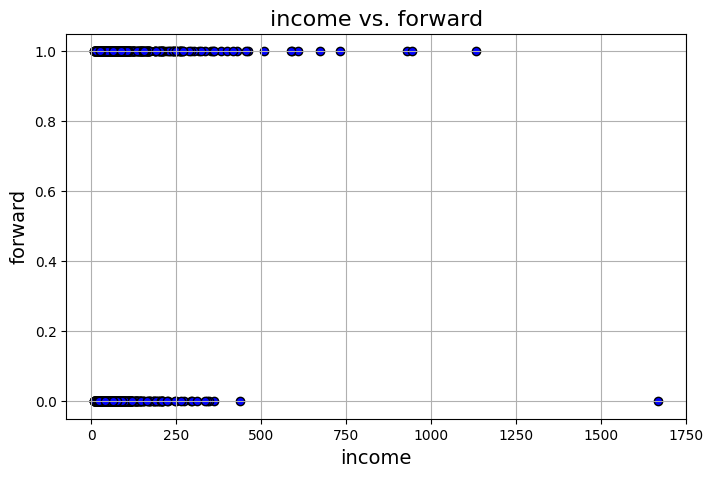

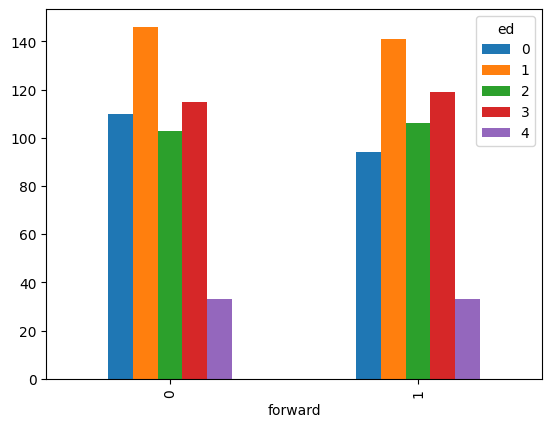

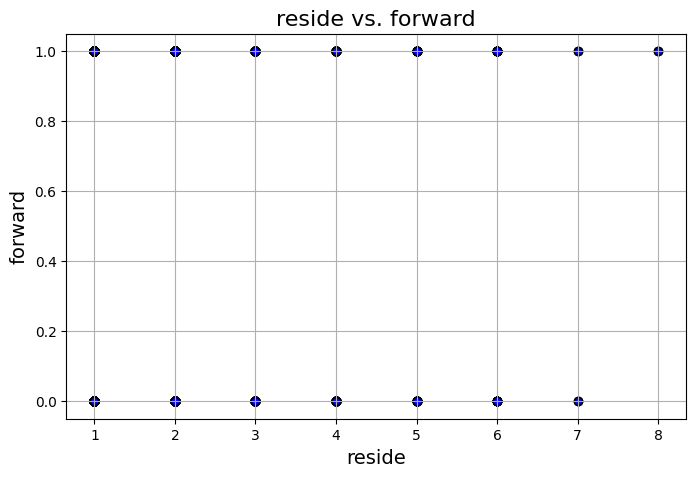

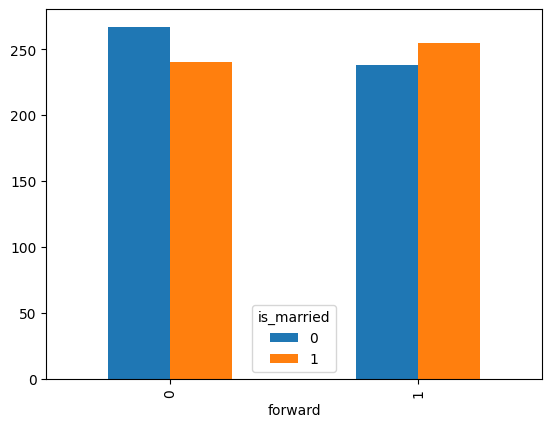

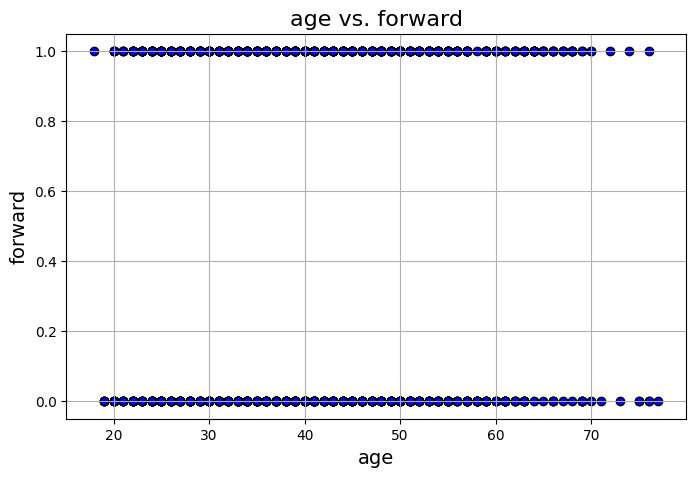

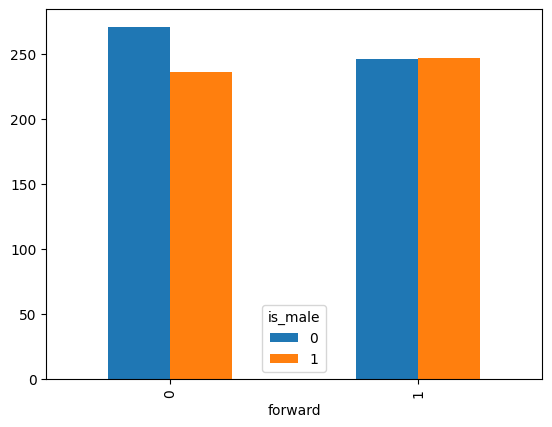

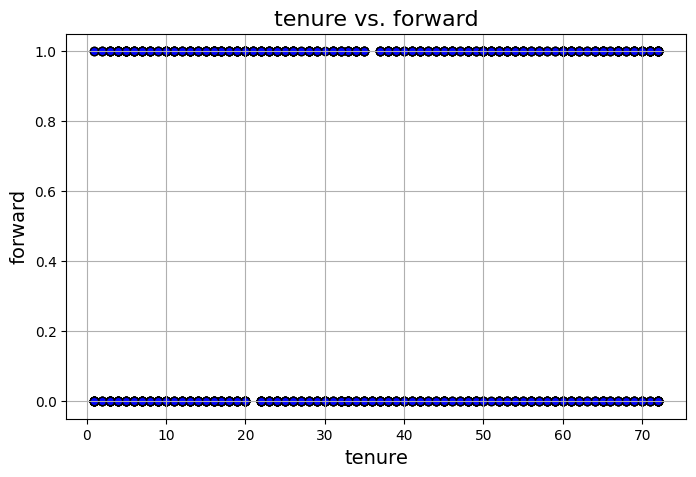

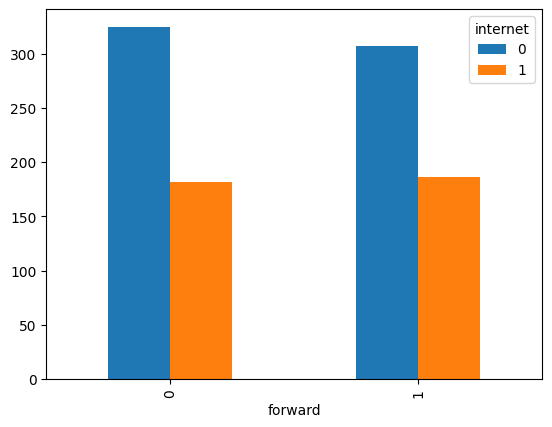

In [ ]:
for c in df1_selected.columns[1:]:
    if c == 'income' or c == 'reside' or c=='age' or c=='tenure':
        plt.figure(figsize=(8,5))
        plt.title('{} vs. forward'.format(c), fontsize=16)
        plt.scatter(x=df1_selected[c], y=df1_selected.forward, color='blue',edgecolor='k')
        plt.grid(True)
        plt.xlabel(c, fontsize=14)
        plt.ylabel('forward', fontsize=14)
        plt.show()
    elif c == 'ed' or c == 'is_married' or c=='is_male' or c=='internet':
        ct = pd.crosstab(df1_selected.forward, df1_selected[c])
        ct.plot.bar()

The analysis shows that income has the strongest association with `forward`, indicating higher financial resources increase the likelihood of the event. Other predictors like education, marital status, residence, age, gender, tenure, and internet access show no meaningful relationship with `forward`. This suggests that these variables either lack predictive power or their influence is overshadowed by other unobserved factors. Focus should be on refining income-related predictors and exploring additional factors or interactions for better insights.

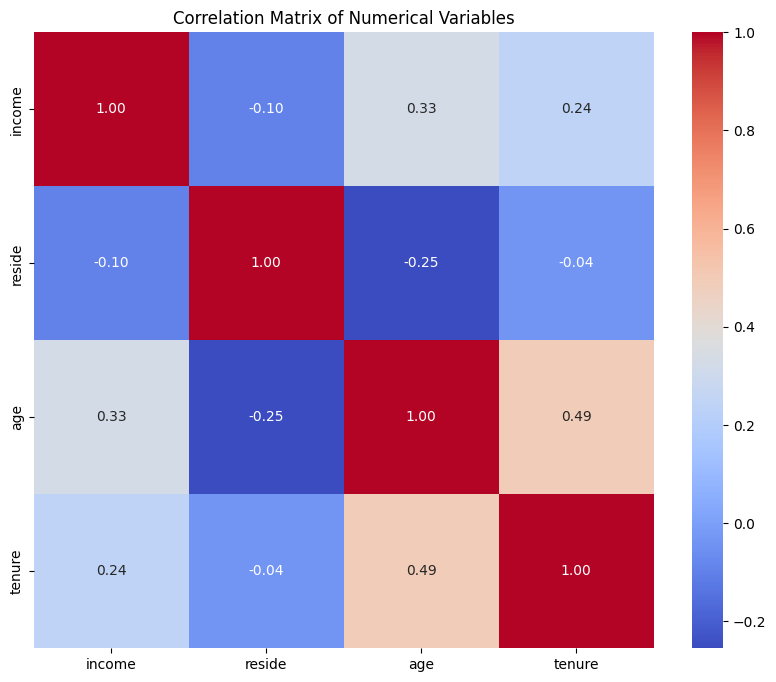

<Figure size 800x600 with 0 Axes>

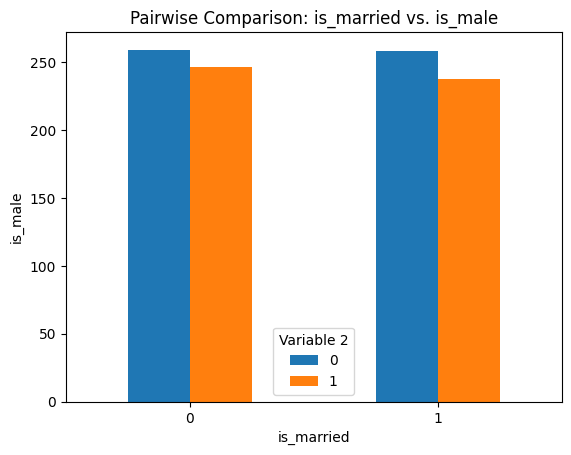

<Figure size 800x600 with 0 Axes>

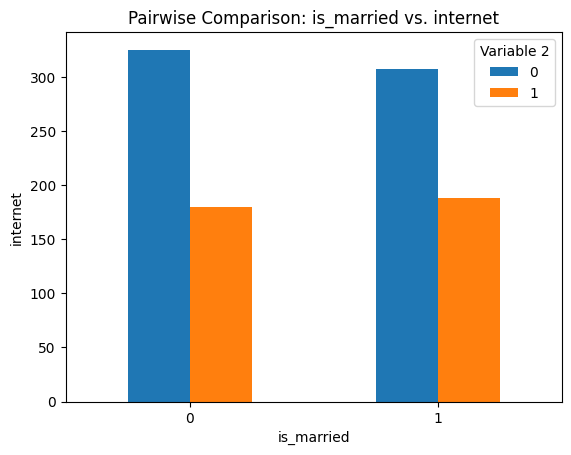

<Figure size 800x600 with 0 Axes>

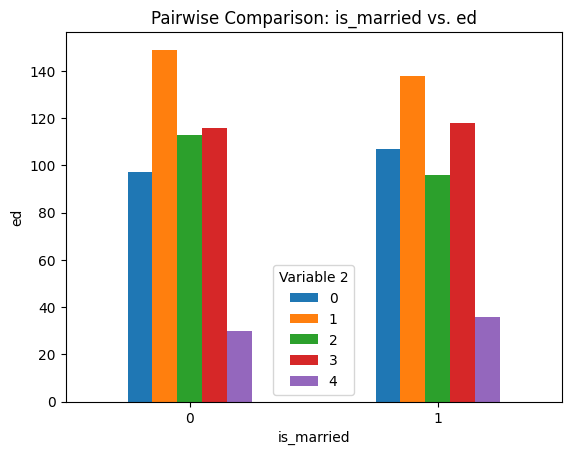

<Figure size 800x600 with 0 Axes>

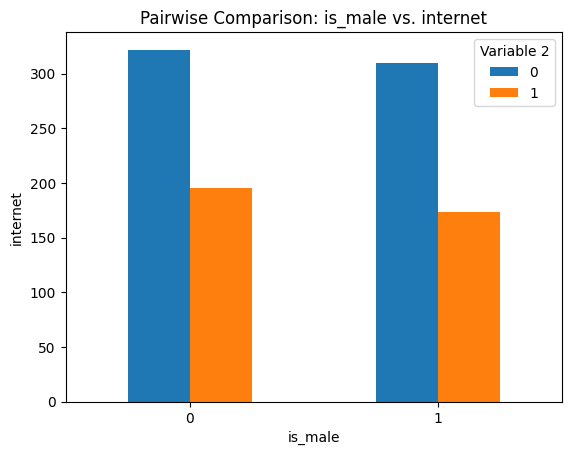

<Figure size 800x600 with 0 Axes>

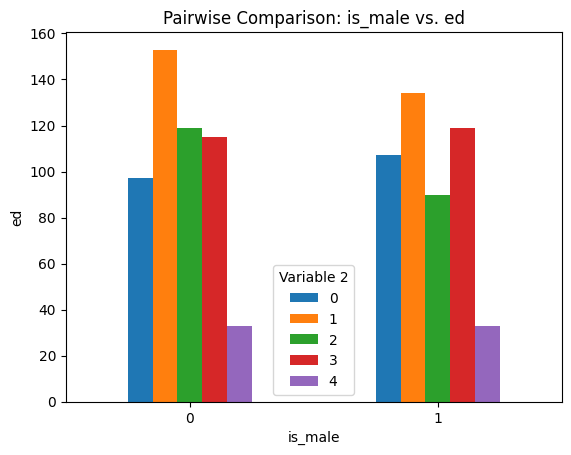

<Figure size 800x600 with 0 Axes>

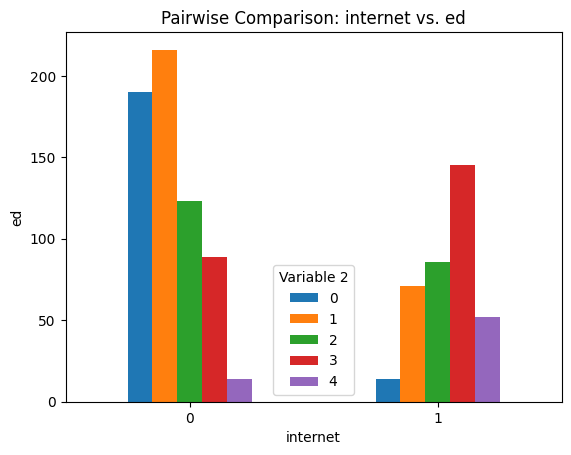

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical variables for correlation matrix
numerical_cols = ['income', 'reside', 'age', 'tenure']

# Boolean variables for bar plots
boolean_cols = ['is_married', 'is_male', 'internet', 'ed']

# Correlation matrix for numerical variables
plt.figure(figsize=(10, 8))
sns.heatmap(df1_selected[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# Pairwise comparisons for boolean variables
for i in range(len(boolean_cols)):
    for j in range(i + 1, len(boolean_cols)):
        col1 = boolean_cols[i]
        col2 = boolean_cols[j]

        plt.figure(figsize=(8, 6))
        ct = pd.crosstab(df1_selected[col1], df1_selected[col2])
        ct.plot(kind='bar', stacked=False)  # Use stacked=False for side-by-side bars
        plt.title(f'Pairwise Comparison: {col1} vs. {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
        plt.legend(title='Variable 2')
        plt.show()

Correlation Matrix of Numerical Variables: Age and tenure have a moderate positive correlation (0.49), while other variables show weak or negligible relationships.

is_married vs. is_male: The proportions of males and females are nearly equal across marital status groups.

is_married vs. internet: Internet access distribution is similar for married and non-married individuals.

is_married vs. ed: Educational levels are similarly distributed between married and non-married individuals.

is_male vs. internet: Internet access distribution is consistent across genders.

is_male vs. ed: Educational levels are uniformly distributed between males and females.

internet vs. ed: Individuals without internet access have a slightly higher distribution across all education levels.

## Hypotheses:

Income Hypothesis:

Null Hypothesis (H0): Income has no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Income has a positive effect on the likelihood of forward = 1.
Education Level Hypothesis:

Null Hypothesis (H0): Education levels (ed_0 to ed_4) have no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Education levels significantly affect the likelihood of forward = 1.
Residence Hypothesis:

Null Hypothesis (H0): Residence (reside) has no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Residence significantly affects the likelihood of forward = 1.
Marital Status Hypothesis:

Null Hypothesis (H0): Marital status (is_married) has no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Marital status significantly affects the likelihood of forward = 1.
Age Hypothesis:

Null Hypothesis (H0): Age has no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Age significantly affects the likelihood of forward = 1.
Gender Hypothesis:

Null Hypothesis (H0): Gender (is_male) has no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Gender significantly affects the likelihood of forward = 1.
Tenure Hypothesis:

Null Hypothesis (H0): Tenure has no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Tenure significantly affects the likelihood of forward = 1.
Internet Access Hypothesis:

Null Hypothesis (H0): Internet access (internet) has no effect on the likelihood of forward = 1.
Alternative Hypothesis (H1): Internet access significantly affects the likelihood of forward = 1.

## Regression

In [ ]:
df1_selected.shape

(1000, 13)

In [ ]:
x_mult = df1_selected[['income', 'ed_0', 'ed_2', 'ed_3', 'ed_4', 'reside', 'is_married', 'age', 'is_male', 'tenure', 'internet']]
y = df1_selected['forward']
x_mult_constant = sm.add_constant(x_mult)

In [ ]:
model1 = sm.Logit(y, x_mult_constant).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.679714
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                forward   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      988
Method:                           MLE   Df Model:                           11
Date:                Sat, 30 Nov 2024   Pseudo R-squ.:                 0.01924
Time:                        11:54:27   Log-Likelihood:                -679.71
converged:                       True   LL-Null:                       -693.05
Covariance Type:            nonrobust   LLR p-value:                  0.005152
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9970      0.319     -3.121      0.002      -1.623      -0.371
income         0.0023      0.

In [ ]:
coefs = pd.DataFrame()
coefs['Coefs'] = model1.params[1:]
coefs['Features'] = model1.params.index[1:]
coefs.set_index('Features', inplace=True)
print('Intercept = ', model1.params[0])
coefs
#regression coefficients

Intercept =  -0.9969895062668731


,Coefs
Features,
income,0.002321
ed_0,-0.127694
ed_2,0.051508
ed_3,0.018447
ed_4,-0.059313
reside,0.092675
is_married,0.005104
age,0.007537
is_male,0.177007


In [ ]:
coefs['OddsRatio'] = np.exp(coefs.Coefs)
coefs
#regression coefficient and odds ratio

,Coefs,OddsRatio
Features,,
income,0.002321,1.002324
ed_0,-0.127694,0.880123
ed_2,0.051508,1.052857
ed_3,0.018447,1.018618
ed_4,-0.059313,0.942412
reside,0.092675,1.097106
is_married,0.005104,1.005117
age,0.007537,1.007565
is_male,0.177007,1.193639


In [ ]:
def yes_no(p_value, level = 0.05):
    if abs(p_value) < level:
        return 'significant'
    else:
        return 'non-significant'

In [ ]:
pvals = pd.DataFrame()
pvals['p_values'] = model1.pvalues[1:]
pvals['5% level']= pvals['p_values'].apply(yes_no)
pvals['p_values'] = pvals['p_values'].map('{:.3f}'.format)
pvals['Features'] = model1.params.index[1:]
pvals.set_index('Features',inplace=True)
pvals

,p_values,5% level
Features,,
income,0.008,significant
ed_0,0.499,non-significant
ed_2,0.783,non-significant
ed_3,0.922,non-significant
ed_4,0.838,non-significant
reside,0.126,non-significant
is_married,0.976,non-significant
age,0.241,non-significant
is_male,0.169,non-significant


In [ ]:
pvals['10% level'] = model1.pvalues[1:].apply(lambda x: yes_no(x, level=0.1))
pvals

,p_values,5% level,10% level
Features,,,
income,0.008,significant,significant
ed_0,0.499,non-significant,non-significant
ed_2,0.783,non-significant,non-significant
ed_3,0.922,non-significant,non-significant
ed_4,0.838,non-significant,non-significant
reside,0.126,non-significant,non-significant
is_married,0.976,non-significant,non-significant
age,0.241,non-significant,non-significant
is_male,0.169,non-significant,non-significant


Income Hypothesis:

 The null hypothesis (H0) is rejected. Income significantly increases the likelihood of forward = 1 (p = 0.008).


Education Level Hypothesis:

 The null hypothesis (H0) is not rejected. Education levels (ed_0 to ed_4) do not significantly affect the likelihood of forward = 1 (p > 0.05 for all).


Residence Hypothesis:

 The null hypothesis (H0) is not rejected. Residence (reside) does not significantly affect the likelihood of forward = 1 (p = 0.131).


Marital Status Hypothesis:

 The null hypothesis (H0) is not rejected. Marital status (is_married) does not significantly affect the likelihood of forward = 1 (p = 0.126).


Age Hypothesis:

 The null hypothesis (H0) is not rejected. Age does not significantly affect the likelihood of forward = 1 (p = 0.241).


Gender Hypothesis:

 The null hypothesis (H0) is not rejected. Gender (is_male) does not significantly affect the likelihood of forward = 1 (p = 0.169).


Tenure Hypothesis:

 The null hypothesis (H0) is not rejected. Tenure does not significantly affect the likelihood of forward = 1 (p = 0.820).


Internet Access Hypothesis:

 The null hypothesis (H0) is not rejected. Internet access does not significantly affect the likelihood of forward = 1 (p = 0.493).

The results show that income is the only factor significantly linked to the outcome (forward) with a positive effect (
p=0.008). This means that 0.0023 higher income increases the chances of forward = 1. All other factors, like education, residence, marital status, age, gender, tenure, and internet access, do not have a meaningful impact (p>0.05). The model explains only a small part of the variation in forward (about 1.92%, based on Pseudo R-squared), meaning its ability to predict the outcome is weak. While the model is statistically significant overall (
p=0.005), it could be improved by adding more relevant predictors.

## Model characteristics

In [ ]:
print('R^2 = {:f}'.format(model1.prsquared))
print('Model significance = {:f}'.format(model1.llr_pvalue))

R^2 = 0.019241
Model significance = 0.005152


The model is statistically significant, however it only explains 1,9% of the variation of the dependent variable.

In [ ]:
f'Statistically significant model parameters: {model1.pvalues[model1.pvalues < 0.05].index.values}'

"Statistically significant model parameters: ['const' 'income']"

In [ ]:
f'Statistically insignificant model parameters: {model1.pvalues[model1.pvalues > 0.05].index.values}'

"Statistically insignificant model parameters: ['ed_0' 'ed_2' 'ed_3' 'ed_4' 'reside' 'is_married' 'age' 'is_male'\n 'tenure' 'internet']"

In [ ]:
l = []
for (param, index) in zip(model1.params[1:], model1.params.index[1:]):
    l.append('{:.2f}*{}'.format(param, index))

print('REGRESSION EQUATION: logit(p) = {:2f} + {}'.format(model1.params[0], ' + '.join(l)))

REGRESSION EQUATION: logit(p) = -0.996990 + 0.00*income + -0.13*ed_0 + 0.05*ed_2 + 0.02*ed_3 + -0.06*ed_4 + 0.09*reside + 0.01*is_married + 0.01*age + 0.18*is_male + 0.00*tenure + 0.10*internet


In [ ]:
cm = model1.pred_table()
print('TP: {} | FN: {}\n-------------------\nFP: {}  | TN: {}'.format(cm[0,0], cm[0,1], cm[1,0], cm[1,1]))

TP: 329.0 | FN: 178.0
-------------------
FP: 256.0  | TN: 237.0


In [ ]:
accuracy = (cm[0,0] + cm[1,1]) / sum(sum(cm))
print('Accuracy: {}'.format(accuracy))

Accuracy: 0.566


The analysis shows that income is the most important predictor of the outcome, with higher income increasing the likelihood of forward = 1. However, other variables like education, residence, marital status, age, gender, tenure, and internet access have little to no meaningful impact. The model's ability to explain the outcome is very limited, with only 1.92% of the variation being captured, indicating that many important factors are likely missing. While the model is statistically significant overall, its predictive power is weak and could be improved by including additional, more relevant variables.

# Panel Data Analisys

Dependent variable:  
- Rabotniki (Number of employees in Small and Medium Enterprises (SMEs) (people))

Predictors:
3 continuous variables which have the highest correlation with the dependent variable + any other 3 variables

In [ ]:
df2 = pd.read_excel('/content/SMEs.xls')

df2.head()

,id,year,Region,District,Rabotniki,SubMSP,Vnovsozd,oborot,InvestFC,fedsub,minekfed,minekreg,fz22344,saldfinresult,newrabmesta,newSMBdo30,naselenie,edu30,biznav,im,infrmoney,infrrazv,suppmsp,vrp,budg
0,1,2016,Moscow,Central,2608366,731632,150349,1.686972e+13,1.883730e+11,705299000.0,705.000000,176,687.0,1181078.00,0.746,0.0,12355400,0,6766.08,104.0,705.000000,23.0,425,1.429980e+07,1.852642e+06
1,1,2017,Moscow,Central,2199321,768618,159342,1.499113e+13,3.439057e+11,555608500.0,0.000000,0,1641.0,1271280.00,0.284,0.0,12380700,0,7048.00,114.0,0.000000,26.0,11401,1.590428e+07,2.000854e+06
2,1,2018,Moscow,Central,2200603,780902,150734,1.467666e+13,1.467666e+13,481000000.0,396.067416,96,1164.0,1838251.44,3.043,0.0,12506468,0,25400.00,152.0,362.164356,28.6,13111,1.780433e+07,2.134911e+06
3,2,2016,Saint Petersburg,Northwestern,1151893,334994,66107,5.854914e+12,2.343767e+10,96443000.0,96.000000,24,335.0,452089.00,0.079,0.0,5253600,100,1585.92,2504.0,121.000000,9.0,3834,3.742182e+06,4.766638e+05
4,2,2017,Saint Petersburg,Northwestern,1082580,347355,64414,4.396981e+12,3.118336e+10,59893240.0,60.000000,140,1396.0,556546.00,0.093,0.0,5281600,122,1652.00,2775.0,200.000000,10.0,7384,4.162067e+06,5.147969e+05


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             255 non-null    int64  
 1   year           255 non-null    int64  
 2   Region         255 non-null    object 
 3   District       255 non-null    object 
 4   Rabotniki      255 non-null    int64  
 5   SubMSP         255 non-null    int64  
 6   Vnovsozd       255 non-null    int64  
 7   oborot         255 non-null    float64
 8   InvestFC       255 non-null    float64
 9   fedsub         253 non-null    float64
 10  minekfed       255 non-null    float64
 11  minekreg       255 non-null    int64  
 12  fz22344        255 non-null    float64
 13  saldfinresult  255 non-null    float64
 14  newrabmesta    255 non-null    float64
 15  newSMBdo30     255 non-null    float64
 16  naselenie      255 non-null    int64  
 17  edu30          255 non-null    int64  
 18  biznav    

In [ ]:
df2 = df2.set_index(["id", "year"])
df2.head()

Region      District  Rabotniki  ...  suppmsp           vrp          budg
id year                                             ...                                     
1  2016            Moscow       Central    2608366  ...      425  1.429980e+07  1.852642e+06
   2017            Moscow       Central    2199321  ...    11401  1.590428e+07  2.000854e+06
   2018            Moscow       Central    2200603  ...    13111  1.780433e+07  2.134911e+06
2  2016  Saint Petersburg  Northwestern    1151893  ...     3834  3.742182e+06  4.766638e+05
   2017  Saint Petersburg  Northwestern    1082580  ...     7384  4.162067e+06  5.147969e+05

[5 rows x 23 columns]

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 255 entries, (1, 2016) to (85, 2018)
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Region         255 non-null    object 
 1   District       255 non-null    object 
 2   Rabotniki      255 non-null    int64  
 3   SubMSP         255 non-null    int64  
 4   Vnovsozd       255 non-null    int64  
 5   oborot         255 non-null    float64
 6   InvestFC       255 non-null    float64
 7   fedsub         253 non-null    float64
 8   minekfed       255 non-null    float64
 9   minekreg       255 non-null    int64  
 10  fz22344        255 non-null    float64
 11  saldfinresult  255 non-null    float64
 12  newrabmesta    255 non-null    float64
 13  newSMBdo30     255 non-null    float64
 14  naselenie      255 non-null    int64  
 15  edu30          255 non-null    int64  
 16  biznav         255 non-null    float64
 17  im             255 non-null    float64


In [ ]:
df2.dropna()

for t in df2.dtypes.unique():
     print('Type: {}\n{}\n'.format(t, df2.dtypes[df2.dtypes==t].index.values))

Type: object
['Region' 'District']

Type: int64
['Rabotniki' 'SubMSP' 'Vnovsozd' 'minekreg' 'naselenie' 'edu30' 'suppmsp']

Type: float64
['oborot' 'InvestFC' 'fedsub' 'minekfed' 'fz22344' 'saldfinresult'
 'newrabmesta' 'newSMBdo30' 'biznav' 'im' 'infrmoney' 'infrrazv' 'vrp'
 'budg']



In [ ]:
df2['Rabotniki'].describe()

,Rabotniki
count,2.550000e+02
mean,1.974494e+05
std,2.988922e+05
min,2.802000e+03
25%,6.326200e+04
50%,1.265800e+05
75%,2.216295e+05
max,2.608366e+06


<Axes: >

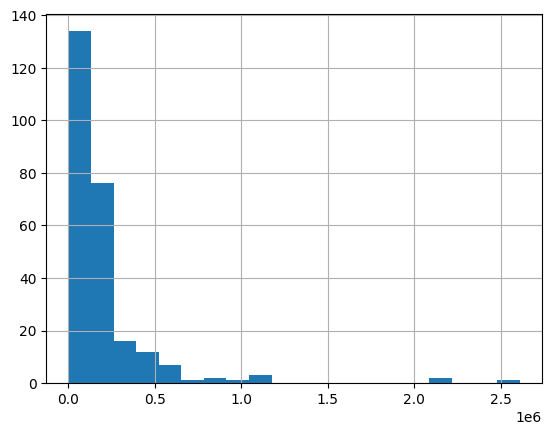

In [ ]:
df2['Rabotniki'].hist(bins=20)

<Axes: xlabel='year'>

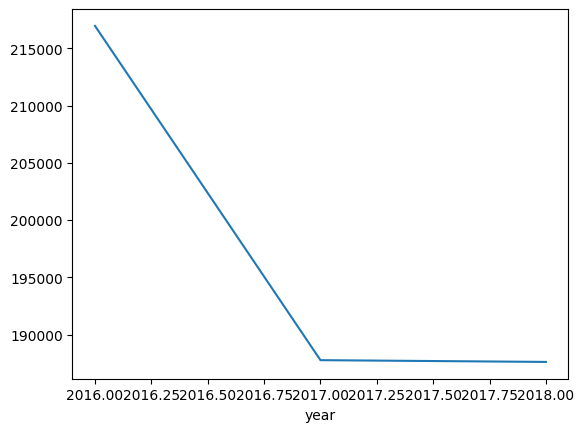

In [ ]:
df2['Rabotniki'].groupby('year').mean().plot()

In [ ]:
numeric_df2 = df2.select_dtypes(include=np.number)

correlation_matrix = numeric_df2.corr()

correlation_matrix

,Rabotniki,SubMSP,Vnovsozd,oborot,InvestFC,fedsub,minekfed,minekreg,fz22344,saldfinresult,newrabmesta,newSMBdo30,naselenie,edu30,biznav,im,infrmoney,infrrazv,suppmsp,vrp,budg
Rabotniki,1.000000,0.983126,0.983551,0.955289,0.507447,0.653200,0.533094,0.482789,0.781645,0.881617,0.480528,0.076769,0.940029,0.044040,0.530082,0.218812,0.513026,0.202945,0.280162,0.919795,0.923145
SubMSP,0.983126,1.000000,0.992373,0.936859,0.554833,0.628912,0.528189,0.494385,0.809989,0.881618,0.491798,0.082298,0.960126,0.052532,0.585435,0.234682,0.512843,0.188472,0.336564,0.924315,0.922163
Vnovsozd,0.983551,0.992373,1.000000,0.963431,0.549911,0.620245,0.495577,0.457377,0.825755,0.907422,0.438519,0.059764,0.940790,0.040842,0.572685,0.200745,0.493244,0.187441,0.304480,0.944528,0.949548
oborot,0.955289,0.936859,0.963431,1.000000,0.536792,0.602555,0.414470,0.343297,0.790586,0.944306,0.326501,-0.020644,0.848403,-0.037446,0.484271,0.114976,0.437321,0.181681,0.245514,0.954838,0.973670
InvestFC,0.507447,0.554833,0.549911,0.536792,1.000000,0.177685,0.262736,0.220912,0.465936,0.702484,0.291560,0.007351,0.490664,0.028893,0.728655,0.146311,0.253375,0.138045,0.269556,0.618288,0.601380
fedsub,0.653200,0.628912,0.620245,0.602555,0.177685,1.000000,0.784563,0.355558,0.373826,0.491083,0.568018,0.233266,0.675453,0.156683,0.143981,-0.018012,0.634807,0.175077,0.128565,0.549279,0.567565
minekfed,0.533094,0.528189,0.495577,0.414470,0.262736,0.784563,1.000000,0.518243,0.194939,0.310690,0.546439,0.429665,0.641316,0.368054,0.416770,0.116981,0.789835,0.213856,0.164105,0.385872,0.380639
minekreg,0.482789,0.494385,0.457377,0.343297,0.220912,0.355558,0.518243,1.000000,0.359813,0.307932,0.331114,0.176679,0.543972,0.199208,0.414713,0.276846,0.767626,0.152844,0.257587,0.394051,0.350472
fz22344,0.781645,0.809989,0.825755,0.790586,0.465936,0.373826,0.194939,0.359813,1.000000,0.817588,0.216320,-0.039472,0.710293,-0.021654,0.429725,0.254237,0.319085,0.109182,0.315966,0.797527,0.796651
saldfinresult,0.881617,0.881618,0.907422,0.944306,0.702484,0.491083,0.310690,0.307932,0.817588,1.000000,0.292106,-0.061717,0.762115,-0.051139,0.534857,0.141197,0.384200,0.153976,0.284378,0.933081,0.946406


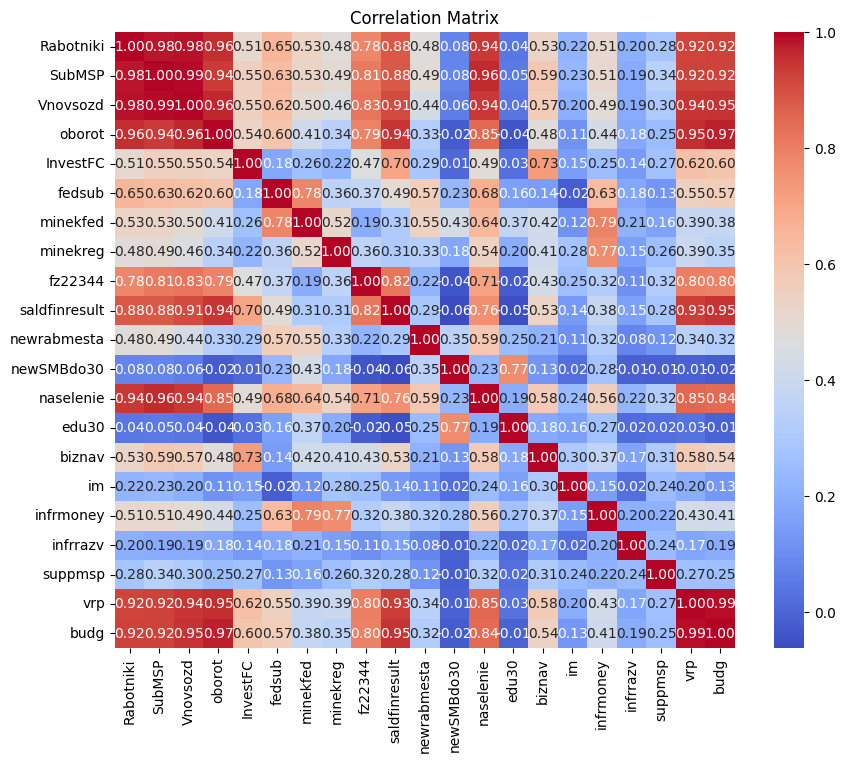

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# prompt: find infs

# Find and print the infinite values in the DataFrame
for col in numeric_df2.columns:
    if np.isinf(numeric_df2[col]).any():
        print(f"Infinite values found in column: {col}")
        print(numeric_df2[col][np.isinf(numeric_df2[col])])

In [ ]:
correlations = correlation_matrix['Rabotniki'].drop('Rabotniki')  # Exclude self-correlation
top_3_correlations = correlations.abs().nlargest(3)

top_3_correlations

,Rabotniki
Vnovsozd,0.983551
SubMSP,0.983126
oborot,0.955289


In [ ]:
df2['Vnovsozd'].describe()

,Vnovsozd
count,255.000000
mean,11484.164706
std,19003.568695
min,155.000000
25%,3391.500000
50%,6667.000000
75%,11641.000000
max,159342.000000


<Axes: >

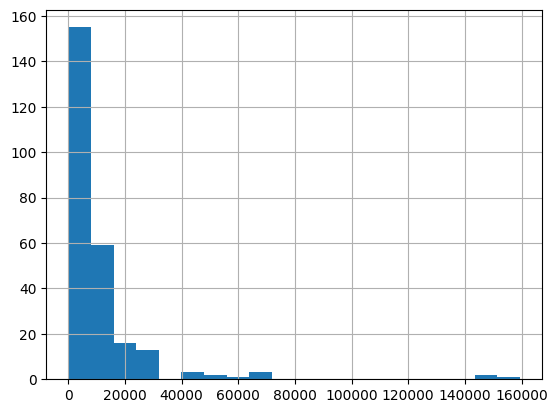

In [ ]:
df2['Vnovsozd'].hist(bins=20)

In [ ]:
df2['SubMSP'].describe()

,SubMSP
count,255.000000
mean,69248.200000
std,98528.129137
min,1334.000000
25%,23034.000000
50%,43250.000000
75%,74101.500000
max,780902.000000


<Axes: >

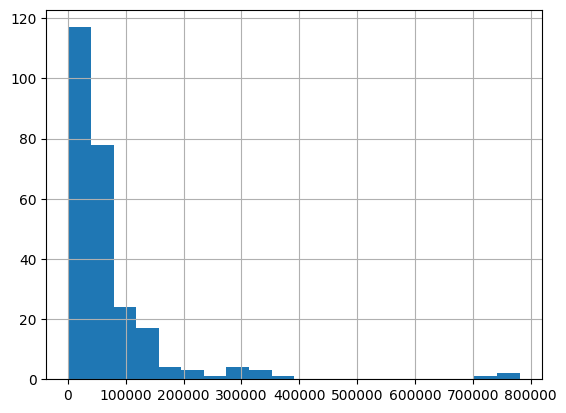

In [ ]:
df2['SubMSP'].hist(bins=20)

In [ ]:
df2['oborot'].describe()

,oborot
count,2.550000e+02
mean,7.030958e+11
std,1.766701e+12
min,7.699658e+09
25%,1.563601e+11
50%,3.229778e+11
75%,5.968934e+11
max,1.686972e+13


<Axes: >

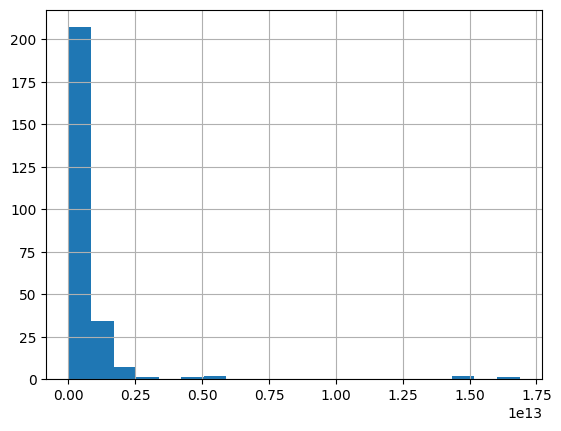

In [ ]:
df2['oborot'].hist(bins=20)

## Hypotheses

Vnovsozd:

Null Hypothesis (H0): There is no relationship between Vnovsozd (newly created businesses) and Rabotniki (number of employees).
Alternative Hypothesis (H1): There is a positive relationship between Vnovsozd (newly created businesses) and Rabotniki (number of employees), indicating that an increase in newly created businesses leads to more employees.


SubMSP:

Null Hypothesis (H0): There is no relationship between SubMSP (subsidized small and medium enterprises) and Rabotniki (number of employees).
Alternative Hypothesis (H1): There is a positive relationship between SubMSP (subsidized SMEs) and Rabotniki (number of employees), suggesting that more subsidized SMEs result in more employment.


Oborot:

Null Hypothesis (H0): There is no relationship between oborot (turnover) and Rabotniki (number of employees).
Alternative Hypothesis (H1): There is a positive relationship between oborot (turnover) and Rabotniki (number of employees), meaning higher turnover is associated with more employees.

## Pooled Model

In [ ]:
exog_vars = ['Vnovsozd', 'SubMSP', 'oborot', 'InvestFC', 'newrabmesta', 'minekfed']
exog = sm.add_constant(df2[exog_vars])
exog.dropna()
mod = PooledOLS(df2["Rabotniki"], exog)
pooled_res = mod.fit()
print(pooled_res)

                          PooledOLS Estimation Summary                          
Dep. Variable:              Rabotniki   R-squared:                        0.9821
Estimator:                  PooledOLS   R-squared (Between):              0.9862
No. Observations:                 255   R-squared (Within):               0.6054
Date:                Sat, Nov 30 2024   R-squared (Overall):              0.9821
Time:                        13:07:39   Log-likelihood                   -3063.6
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      2265.1
Entities:                          85   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,248)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             2265.1
                            

## Fixed effects model

In [ ]:
mod = PanelOLS(df2["Rabotniki"], exog, entity_effects=True, drop_absorbed=True)
fe_res = mod.fit()
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:              Rabotniki   R-squared:                        0.6081
Estimator:                   PanelOLS   R-squared (Between):              0.9158
No. Observations:                 255   R-squared (Within):               0.6081
Date:                Sat, Nov 30 2024   R-squared (Overall):              0.9125
Time:                        13:07:39   Log-likelihood                   -2881.1
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      130.35
Entities:                          85   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(2,168)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             130.35
                            

<ipython-input-197-b6500862b2c7>:2: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

Vnovsozd, SubMSP, newrabmesta, minekfed

  fe_res = mod.fit()


## Random Effects Regression

In [ ]:
mod = RandomEffects(df2.Rabotniki, exog)
re_res = mod.fit(cov_type='clustered', cluster_entity=True)
print(re_res)

                        RandomEffects Estimation Summary                        
Dep. Variable:              Rabotniki   R-squared:                        0.9675
Estimator:              RandomEffects   R-squared (Between):              0.9834
No. Observations:                 255   R-squared (Within):               0.7235
Date:                Sat, Nov 30 2024   R-squared (Overall):              0.9806
Time:                        13:07:39   Log-likelihood                   -2919.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1229.2
Entities:                          85   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                   F(6,248)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             1820.4
                            

## Breusch-Pagan Lagrange Multiplier Test for Random Effects

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 255 entries, (1, 2016) to (85, 2018)
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Region         255 non-null    object 
 1   District       255 non-null    object 
 2   Rabotniki      255 non-null    int64  
 3   SubMSP         255 non-null    int64  
 4   Vnovsozd       255 non-null    int64  
 5   oborot         255 non-null    float64
 6   InvestFC       255 non-null    float64
 7   fedsub         253 non-null    float64
 8   minekfed       255 non-null    float64
 9   minekreg       255 non-null    int64  
 10  fz22344        255 non-null    float64
 11  saldfinresult  255 non-null    float64
 12  newrabmesta    255 non-null    float64
 13  newSMBdo30     255 non-null    float64
 14  naselenie      255 non-null    int64  
 15  edu30          255 non-null    int64  
 16  biznav         255 non-null    float64
 17  im             255 non-null    float64


In [ ]:
df2

Region      District  Rabotniki  ...  suppmsp           vrp          budg
id year                                                     ...                                     
1  2016                    Moscow       Central    2608366  ...      425  1.429980e+07  1.852642e+06
   2017                    Moscow       Central    2199321  ...    11401  1.590428e+07  2.000854e+06
   2018                    Moscow       Central    2200603  ...    13111  1.780433e+07  2.134911e+06
2  2016          Saint Petersburg  Northwestern    1151893  ...     3834  3.742182e+06  4.766638e+05
   2017          Saint Petersburg  Northwestern    1082580  ...     7384  4.162067e+06  5.147969e+05
...                           ...           ...        ...  ...      ...           ...           ...
84 2017             Tuva Republic      Siberian       8328  ...     1490  5.808069e+04  2.463497e+04
   2018             Tuva Republic      Siberian       8788  ...     1714  6.501945e+04  2.628552e+04
85 2016  Jewish Autonomous Oblast   Far Eastern      12163  ...       68  4.687220e+04  9.741238e+03
   2017  Jewish Autonomous Oblast   Far Eastern      12882  ...     1316  5.213140e+04  1.052054e+04
   2018  Jewish Autonomous Oblast   Far Eastern      11910  ...     1513  5.835942e+04  1.122541e+04

[255 rows x 23 columns]

In [ ]:
exog.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 255 entries, (1, 2016) to (85, 2018)
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   const        255 non-null    float64
 1   Vnovsozd     255 non-null    int64  
 2   SubMSP       255 non-null    int64  
 3   oborot       255 non-null    float64
 4   InvestFC     255 non-null    float64
 5   newrabmesta  255 non-null    float64
 6   minekfed     255 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 17.4 KB


In [ ]:
exog

const  Vnovsozd  SubMSP        oborot      InvestFC  newrabmesta    minekfed
id year                                                                              
1  2016    1.0    150349  731632  1.686972e+13  1.883730e+11        0.746  705.000000
   2017    1.0    159342  768618  1.499113e+13  3.439057e+11        0.284    0.000000
   2018    1.0    150734  780902  1.467666e+13  1.467666e+13        3.043  396.067416
2  2016    1.0     66107  334994  5.854914e+12  2.343767e+10        0.079   96.000000
   2017    1.0     64414  347355  4.396981e+12  3.118336e+10        0.093   60.000000
...        ...       ...     ...           ...           ...          ...         ...
84 2017    1.0      1327    6845  1.103968e+10 -2.698255e+08        0.075   23.000000
   2018    1.0      1485    6922  1.422781e+10  1.422781e+10        0.047   25.280899
85 2016    1.0       606    4322  2.527910e+10  3.717700e+08        0.156    7.000000
   2017    1.0       547    4203  2.104477e+10  3.070902e+08        0.020    4.000000
   2018    1.0       595    4156  2.199281e+10  2.199281e+10        0.035    6.179775

[255 rows x 7 columns]

In [ ]:
residuals_pooled_OLS = pooled_res.resids
pooled_OLS_dataset = pd.concat([df2, residuals_pooled_OLS], axis=1)
breusch_pagan_test_results = het_breuschpagan(pooled_OLS_dataset['Rabotniki'], exog)
print('P-value:', breusch_pagan_test_results[3])

P-value: 4.363970091874821e-198


H0 is accepted as p-value < 0.05 => there are no individual effects and pooled model is selected

The analysis highlights that SubMSP, oborot, newrabmesta, and minekfed have significant positive impacts on employment, while InvestFC shows a significant negative effect. Vnovsozd is not a significant predictor of employment in this analysis. These findings suggest that policies supporting SMEs, increasing turnover, creating jobs, and government expenditures are effective strategies for boosting employment.

The panel data analysis shows that the model explains 98.21% of the variation in the number of employees (Rabotniki), indicating a strong fit. The analysis finds that SubMSP (subsidized SMEs), oborot (turnover), newrabmesta (new jobs created), and minekfed (federal expenditures) have significant positive effects on employment. For example, an increase in subsidized SMEs by one unit leads to 2.34 additional employees on average, while creating one new job adds approximately 23,280 employees. Turnover also has a positive, though small, effect on employment, and higher federal expenditures are linked to an increase in employees.

In contrast, InvestFC (investment in fixed capital) shows a significant negative relationship, indicating that higher investments are associated with fewer employees. However, Vnovsozd (newly created businesses) is not statistically significant, meaning it has no meaningful effect on employment in this analysis. These results suggest that policies supporting SMEs, job creation, and federal investments are more effective at increasing employment than fixed capital investments or the creation of new businesses.